In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
titanic_df = pd.read_csv("/content/drive/MyDrive/Data Science and Machine Learning/titanic-data.csv")

In [4]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Inserting and deleting columns and rows

In [5]:
titanic_df.drop([0,2,5], axis = 0, inplace = True)

>>inplace=True make the change directly to the original DataFrame instead of creating and returning a new DataFrame.

In [6]:
last_name = [ name.split(",")[0] for name in titanic_df['Name']]
titanic_df["Last_Name"] = last_name

In [7]:
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Last_Name
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,McCarthy
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Palsson


In [8]:
# Age catagory
bins = [0, 12, 18, 35, 60, 100]

labels = ["Child", "Teenager", "Young Adult", "Adult", "Senior"]

titanic_df["age_catagory"] = pd.cut(
    titanic_df["Age"],
    bins=bins,
    labels=labels
)

titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Last_Name,age_catagory
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Young Adult
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,McCarthy,Adult
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Palsson,Child


In [9]:
# adding the row
titanic_df.loc[900, :] = [900,0,3,"Roktover captiain","male",44,0,0,349909,51,"E46","S", "Roktover","Adult"]

In [10]:
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Last_Name,age_catagory
1,2.0,1.0,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,C85,C,Cumings,Adult
3,4.0,1.0,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,C123,S,Futrelle,Young Adult
4,5.0,0.0,3.0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,NaN,S,Allen,Young Adult
6,7.0,0.0,1.0,"McCarthy, Mr. Timothy J",male,54.0,0.0,0.0,17463,51.8625,E46,S,McCarthy,Adult
7,8.0,0.0,3.0,"Palsson, Master. Gosta Leonard",male,2.0,3.0,1.0,349909,21.0750,NaN,S,Palsson,Child
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
887,888.0,1.0,1.0,"Graham, Miss. Margaret Edith",female,19.0,0.0,0.0,112053,30.0000,B42,S,Graham,Young Adult
888,889.0,0.0,3.0,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1.0,2.0,W./C. 6607,23.4500,NaN,S,Johnston,NaN
889,890.0,1.0,1.0,"Behr, Mr. Karl Howell",male,26.0,0.0,0.0,111369,30.0000,C148,C,Behr,Young Adult
890,891.0,0.0,3.0,"Dooley, Mr. Patrick",male,32.0,0.0,0.0,370376,7.7500,NaN,Q,Dooley,Young Adult


## Handling NaN or Null Values
1. Remove null values
2. Imputation (replacing null value with some value)

In [11]:
titanic_df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,176
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
# remove null value
titanic_df_filter = titanic_df.dropna(subset ="Cabin", axis = 0, how ="any", ignore_index=True)

In [13]:
titanic_df_filter.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,19
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:
mean_age =titanic_df["Age"].mean()

<Axes: ylabel='Frequency'>

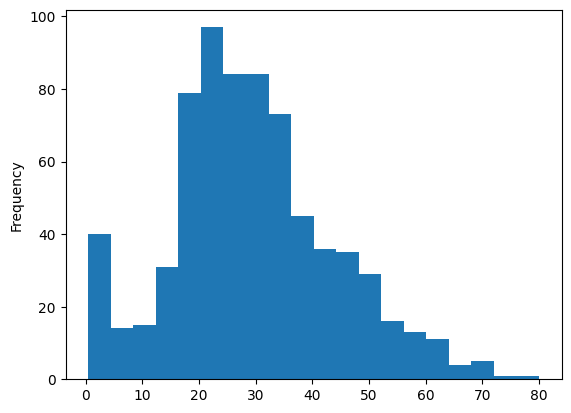

In [15]:
titanic_df.Age.plot.hist(bins=20)

In [16]:
from numpy import mean
# fill
titanic_df["Age"].fillna(mean_age, axis=0, inplace=True)
titanic_df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: ylabel='Frequency'>

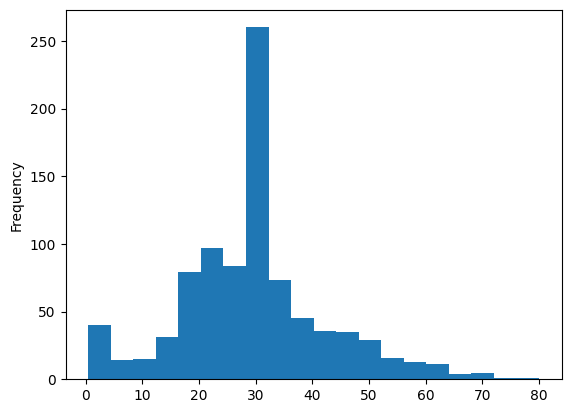

In [17]:
titanic_df.Age.plot.hist(bins=20)

Imputation of Age column with respect to groupby

In [26]:
titanic_df_2 = pd.read_csv("/content/drive/MyDrive/Data Science and Machine Learning/titanic-data.csv")

In [27]:
mean_age = titanic_df_2.groupby("Sex")["Age"].transform("mean")

In [28]:
titanic_df_2["Age"].fillna(mean_age, axis=0, inplace=True)

/tmp/ipykernel_469/4127899240.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df_2["Age"].fillna(mean_age, axis=0, inplace=True)


<Axes: ylabel='Frequency'>

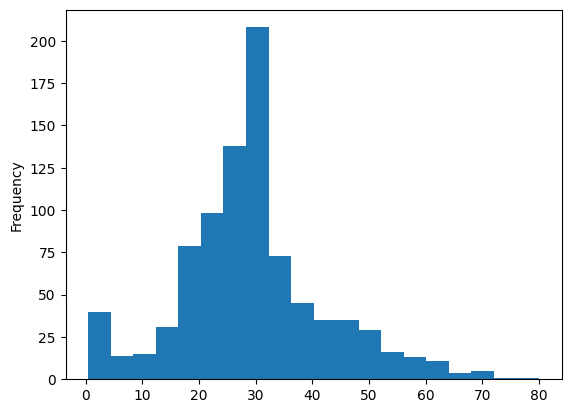

In [29]:
titanic_df_2.Age.plot.hist(bins=20)

In [31]:
titanic_df_2.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [32]:
import pandas as pd

# 1. Create a sample DataFrame
df = pd.DataFrame({
    'Store': ['A', 'A', 'B', 'B', 'B'],
    'Sales': [100, 200, 150, 250, 500]
})

# 2. Calculate the group mean and assign it to a new column
df['Store_Mean_Sales'] = df.groupby('Store')['Sales'].transform('mean')

print(df)

  Store  Sales  Store_Mean_Sales
0     A    100             150.0
1     A    200             150.0
2     B    150             300.0
3     B    250             300.0
4     B    500             300.0


In [33]:
# feature from null value
titanic_df_2.Cabin

,Cabin
0,NaN
1,C85
2,NaN
3,C123
4,NaN
...,...
886,NaN
887,B42
888,NaN
889,C148


In [34]:
titanic_df_Cabin= titanic_df.Cabin.notna().astype(int)
titanic_df_Cabin

,Cabin
0,0
1,1
2,0
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [35]:
titanic_df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


<Axes: >

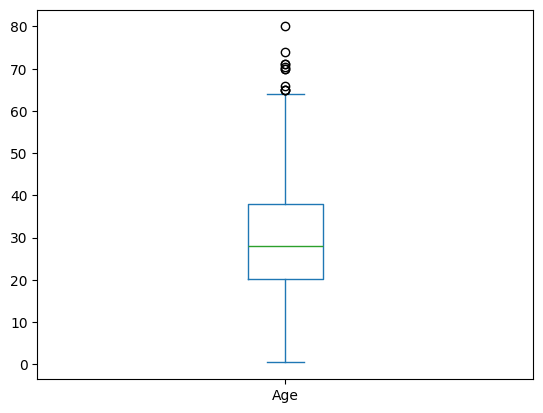

In [36]:
titanic_df.Age.plot.box()